This notebook outlines a pipeline for preprocessing and preparing brain tumor MRI data from the BRATS dataset for semantic segmentation tasks. The approach begins by selecting a single imaging modality (default: FLAIR) from the multi-modal NIfTI volumes and extracting 2D slices along the axial axis. To focus the learning process on meaningful regions, only slices that contain tumor pixels are retained. Each slice is normalized and resized to 256×256 pixels to meet the input size requirements of modern convolutional neural networks. The resulting image-mask pairs are saved in a structured format as .npy files for efficient loading during model training.

A custom PyTorch Dataset class is created to facilitate loading and transforming the preprocessed data. It integrates with the Albumentations library to apply data augmentation techniques that enhance model generalization. This setup enables seamless integration with deep learning models, allowing me to experiment with state-of-the-art segmentation architectures such as 2D U-Net. The design emphasizes modularity, enabling flexible adjustments to modality selection, preprocessing routines, and model training strategies.

In [1]:
import os
import json
import numpy as np
import nibabel as nib
import cv2
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset
from pathlib import Path
import matplotlib.pyplot as plt
import random
from glob import glob
import segmentation_models_pytorch as smp
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import confusion_matrix
np.random.seed(42)
import albumentations as A
from albumentations.pytorch import ToTensorV2

JSON_PATH = './dataset/dataset.json'
BASE_DIR = Path('./dataset').resolve()
OUTPUT_DIR = './preprocessed'
MODALITY_INDEX = 0  # 0=FLAIR, 1=T1w, 2=T1gd, 3=T2w

In [2]:
def resize_to_256(image, mask):
    image_resized = cv2.resize(image[0], (256, 256), interpolation=cv2.INTER_LINEAR)
    mask_resized = cv2.resize(mask, (256, 256), interpolation=cv2.INTER_NEAREST)
    return np.expand_dims(image_resized, axis=0), mask_resized

In [3]:
def load_volume_pairs(json_path, base_dir):
    with open(json_path) as f:
        data = json.load(f)
    all_pairs = [
        {
            "image": os.path.join(base_dir, item["image"].lstrip("./")),
            "label": os.path.join(base_dir, item["label"].lstrip("./"))
        }
        for item in data["training"]
    ]
    return all_pairs

In [4]:
def preprocess_and_save(image_label_pairs, output_dir, modality_index=0):
    os.makedirs(os.path.join(output_dir, 'images'), exist_ok=True)
    os.makedirs(os.path.join(output_dir, 'masks'), exist_ok=True)
    index = 0

    for pair in tqdm(image_label_pairs, desc=f"Preprocessing to {output_dir}"):
        img = nib.load(pair['image']).get_fdata()[..., modality_index]
        mask = nib.load(pair['label']).get_fdata()

        for i in range(img.shape[2]):
            # only tumor slices
            if np.any(mask[:, :, i] > 0):  
                image_slice = img[:, :, i]
                mask_slice = mask[:, :, i]

                # Normalize
                image_norm = (image_slice - np.mean(image_slice)) / (np.std(image_slice) + 1e-5)
                image = np.expand_dims(image_norm, axis=0)

                # Resize
                image_resized, mask_resized = resize_to_256(image, mask_slice)

                # Save
                np.save(os.path.join(output_dir, 'images', f'{index:06d}.npy'), image_resized)
                np.save(os.path.join(output_dir, 'masks', f'{index:06d}.npy'), mask_resized)
                index += 1

    print(f"Saved {index} 2D slices to {output_dir}")

In [5]:
class BRATSPreprocessedDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.image_dir = os.path.join(data_dir, 'images')
        self.mask_dir = os.path.join(data_dir, 'masks')
        self.filenames = sorted(os.listdir(self.image_dir))
        self.transform = transform

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        image = np.load(os.path.join(self.image_dir, self.filenames[idx]))
        mask = np.load(os.path.join(self.mask_dir, self.filenames[idx]))

        image = image[0]  # shape: (256, 256)
        mask = mask.astype(np.uint8)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask'].long()
        else:
            image = torch.tensor(image).unsqueeze(0).float()
            mask = torch.tensor(mask).long()

        return image, mask

In [7]:
# 1. Load full list of volumes
all_volumes = load_volume_pairs(JSON_PATH, BASE_DIR)

# 2. Split by volume
train_vols, valtest_vols = train_test_split(all_volumes, test_size=0.3, random_state=42)
val_vols, test_vols = train_test_split(valtest_vols, test_size=0.5, random_state=42)

# 3. Preprocess and save slices from each split
preprocess_and_save(train_vols, os.path.join(OUTPUT_DIR, 'train'), modality_index=MODALITY_INDEX)
preprocess_and_save(val_vols, os.path.join(OUTPUT_DIR, 'val'), modality_index=MODALITY_INDEX)
preprocess_and_save(test_vols, os.path.join(OUTPUT_DIR, 'test'), modality_index=MODALITY_INDEX)

Preprocessing to ./preprocessed\train: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 338/338 [02:19<00:00,  2.42it/s]


Saved 23659 2D slices to ./preprocessed\train


Preprocessing to ./preprocessed\val: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 73/73 [00:26<00:00,  2.74it/s]


Saved 5068 2D slices to ./preprocessed\val


Preprocessing to ./preprocessed\test: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 73/73 [00:41<00:00,  1.76it/s]

Saved 5028 2D slices to ./preprocessed\test


In [8]:
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.GaussianBlur(p=0.1),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(mean=0.0, std=1.0),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Normalize(mean=0.0, std=1.0),
    ToTensorV2()
])

In [9]:
# 4. Load ready-to-train datasets
train_dataset = BRATSPreprocessedDataset(os.path.join(OUTPUT_DIR, 'train'), transform=train_transform)
val_dataset = BRATSPreprocessedDataset(os.path.join(OUTPUT_DIR, 'val'), transform=val_transform)
test_dataset = BRATSPreprocessedDataset(os.path.join(OUTPUT_DIR, 'test'), transform=val_transform)

print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

BATCH_SIZE = 16
NUM_WORKERS = 0 # for windows 

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

23659
5068
5028


In [10]:
def visualize_predictions_from_dataset(dataset, num_samples=2, title=''):
    indices = random.sample(range(len(dataset)), num_samples)
    for i, idx in enumerate(indices):
        image, mask = dataset[idx]
        image = image.squeeze().numpy()
        mask = mask.numpy()

        plt.figure(figsize=(8, 3))
        plt.suptitle(f"{title} Sample {i + 1}", fontsize=14)

        plt.subplot(1, 2, 1)
        plt.imshow(image, cmap='gray')
        plt.title('Image')
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(mask, cmap='nipy_spectral')
        plt.title('Mask')
        plt.axis('off')

        plt.tight_layout()
        plt.show()

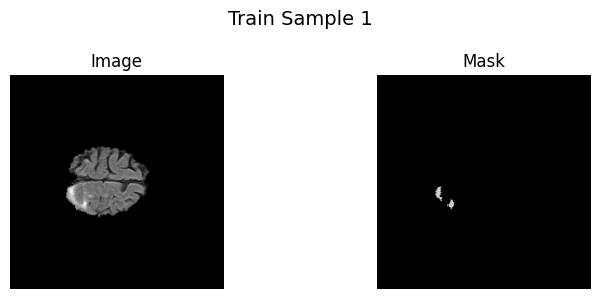

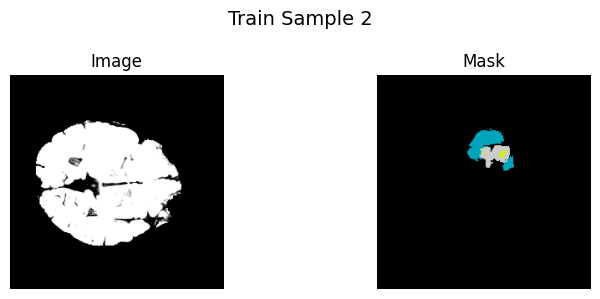

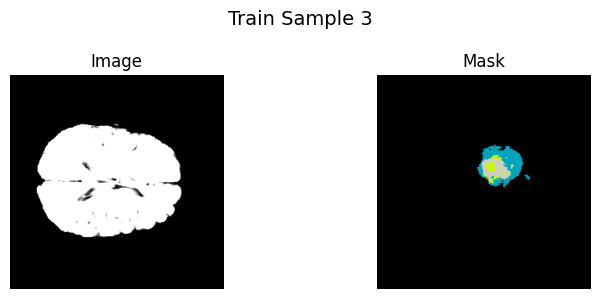

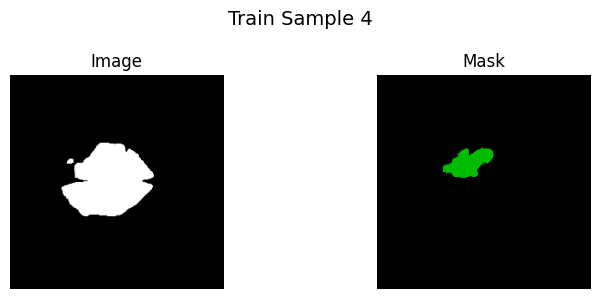

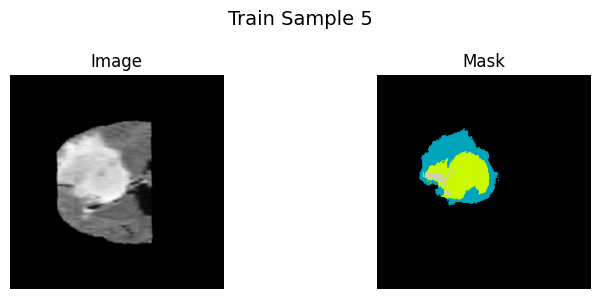

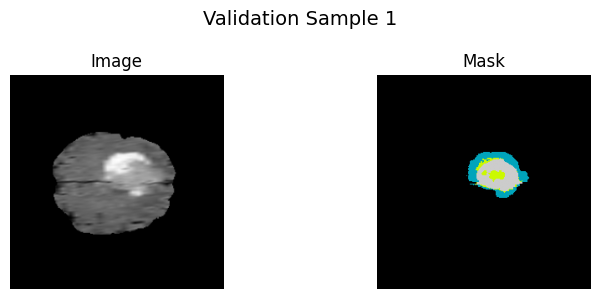

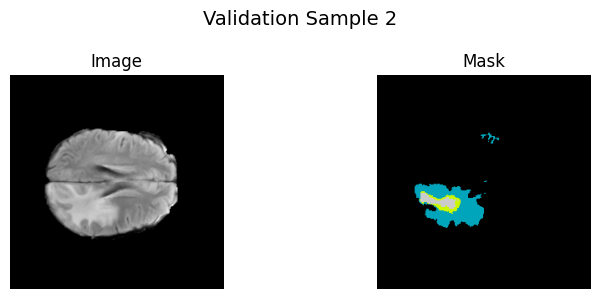

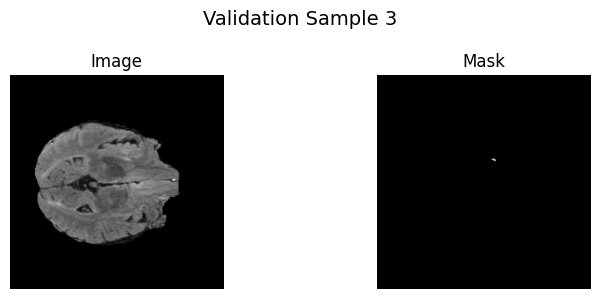

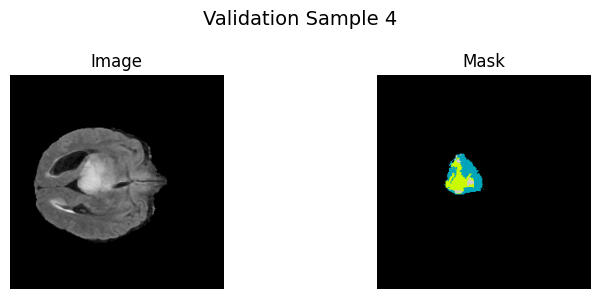

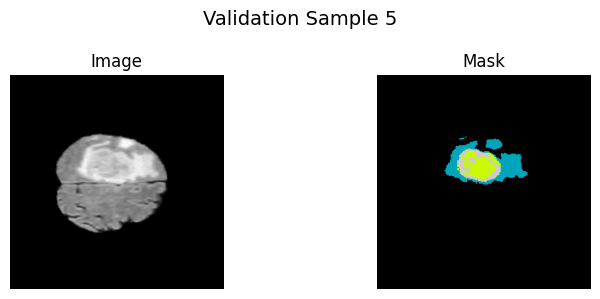

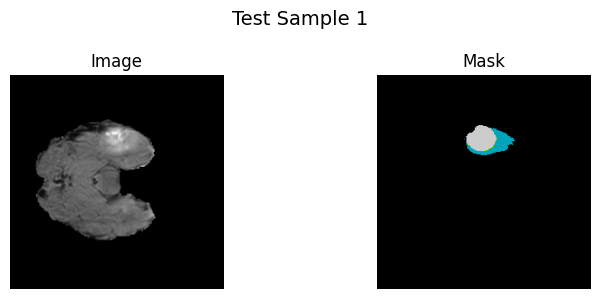

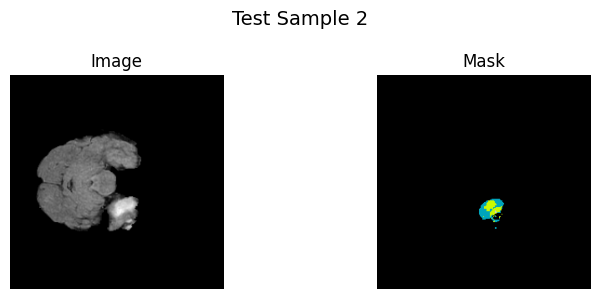

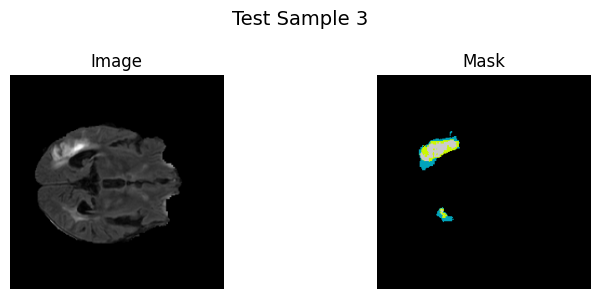

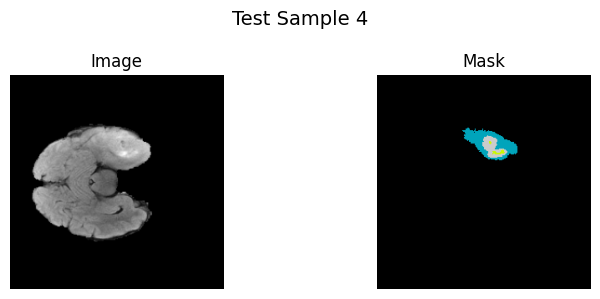

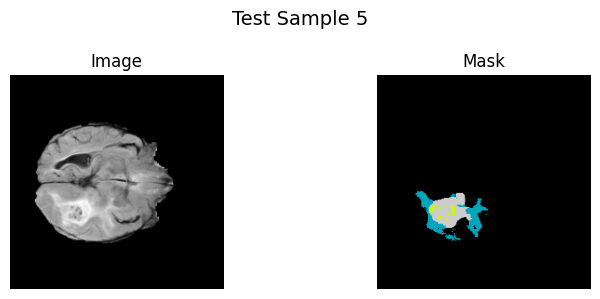

In [11]:
visualize_predictions_from_dataset(train_dataset, num_samples=5, title='Train')
visualize_predictions_from_dataset(val_dataset, num_samples=5, title='Validation')
visualize_predictions_from_dataset(test_dataset, num_samples=5, title='Test')

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class UNet2D(nn.Module):
    def __init__(self, in_channels=1, out_channels=4, features=[64, 128, 256, 512]):
        super(UNet2D, self).__init__()

        self.encoder = nn.ModuleList()
        self.decoder = nn.ModuleList()

        # Encoder (Down)
        for feature in features:
            self.encoder.append(self._conv_block(in_channels, feature))
            in_channels = feature

        # Bottleneck
        self.bottleneck = self._conv_block(features[-1], features[-1]*2)

        # Decoder (Up)
        for feature in reversed(features):
            self.decoder.append(nn.ConvTranspose2d(feature*2, feature, kernel_size=2, stride=2))
            self.decoder.append(self._conv_block(feature*2, feature))

        # Final output layer
        self.output_layer = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def _conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        skip_connections = []
        for down in self.encoder:
            x = down(x)
            skip_connections.append(x)
            x = F.max_pool2d(x, kernel_size=2, stride=2)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        for idx in range(0, len(self.decoder), 2):
            x = self.decoder[idx](x)
            skip_connection = skip_connections[idx // 2]

            if x.shape != skip_connection.shape:
                x = F.interpolate(x, size=skip_connection.shape[2:])

            x = torch.cat((skip_connection, x), dim=1)
            x = self.decoder[idx + 1](x)

        return self.output_layer(x)


In [13]:
def get_pretrained_unet(encoder='resnet34', encoder_weights='imagenet', in_channels=1, classes=4):
    model = smp.Unet(
        encoder_name=encoder,
        encoder_weights=encoder_weights,
        in_channels=in_channels, # 1 for grayscale
        classes=classes,
        activation=None
    )
    return model

In [14]:
def dice_score(preds, targets, num_classes=4):
    preds = torch.argmax(preds, dim=1)
    dice = []

    for cls in range(num_classes):
        pred_cls = (preds == cls).float()
        target_cls = (targets == cls).float()

        intersection = (pred_cls * target_cls).sum()
        union = pred_cls.sum() + target_cls.sum()
        dice_cls = (2. * intersection + 1e-5) / (union + 1e-5)
        dice.append(dice_cls.item())
    
    return sum(dice) / len(dice)

In [15]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_score is None:
            self.best_score = val_loss
        elif val_loss > self.best_score - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = val_loss
            self.counter = 0


In [16]:
def train_model(model, train_dataset, val_dataset=None, num_epochs=10, batch_size=8, lr=1e-3,
                device='cuda' if torch.cuda.is_available() else 'cpu', save_path='model_best.pth'):
    from torch.utils.data import DataLoader
    import torch.nn as nn
    import torch.optim as optim
    import matplotlib.pyplot as plt
    from tqdm import tqdm

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False) if val_dataset else None

    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    stopper = EarlyStopping(patience=8)

    train_losses, val_losses = [], []
    train_dices, val_dices = [], []
    best_val_loss = float('inf')

    for epoch in range(num_epochs):
        model.train()
        train_loss, train_dice = 0.0, 0.0
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")

        for images, masks in loop:
            images, masks = images.to(device), masks.to(device)
            preds = model(images)
            loss = criterion(preds, masks)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_dice += dice_score(preds, masks)
            loop.set_postfix(loss=loss.item())

        avg_loss = train_loss / len(train_loader)
        avg_dice = train_dice / len(train_loader)
        train_losses.append(avg_loss)
        train_dices.append(avg_dice)

        print(f"Train Loss: {avg_loss:.4f}, Dice: {avg_dice:.4f}")

        if val_loader:
            model.eval()
            val_loss, val_dice = 0.0, 0.0
            with torch.no_grad():
                for images, masks in val_loader:
                    images, masks = images.to(device), masks.to(device)
                    preds = model(images)
                    loss = criterion(preds, masks)
                    val_loss += loss.item()
                    val_dice += dice_score(preds, masks)

            avg_val_loss = val_loss / len(val_loader)
            avg_val_dice = val_dice / len(val_loader)
            val_losses.append(avg_val_loss)
            val_dices.append(avg_val_dice)

            print(f"Val Loss: {avg_val_loss:.4f}, Dice: {avg_val_dice:.4f}")

            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                torch.save(model.state_dict(), save_path)
                print(f"Best model saved at epoch {epoch+1}.")

            stopper(avg_val_loss)
            if stopper.early_stop:
                print("Early stopping triggered.")
                break

    # Plotting
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    if val_losses: plt.plot(val_losses, label='Val Loss')
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Loss Curve")
    plt.legend(); plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(train_dices, label='Train Dice')
    if val_dices: plt.plot(val_dices, label='Val Dice')
    plt.xlabel("Epoch"); plt.ylabel("Dice Score"); plt.title("Dice Score Curve")
    plt.legend(); plt.grid(True)
    plt.tight_layout()
    plt.show()

    return model


In [17]:
model_2D_UNET = get_pretrained_unet(encoder='resnet34', encoder_weights='imagenet')
model_2D_UNET_pretrained = get_pretrained_unet(encoder='resnet34', encoder_weights='imagenet')
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model_2D_UNET.to(device)
model_2D_UNET_pretrained.to(device)

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [18]:
def evaluate_metrics(model, dataset, num_classes=4, device='cuda' if torch.cuda.is_available() else 'cpu'):
    model.eval()
    loader = DataLoader(dataset, batch_size=1, shuffle=False)
    
    dice_scores = np.zeros(num_classes)
    total_pixels = 0
    correct_pixels = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for images, masks in tqdm(loader, desc="Evaluating"):
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            # Pixel accuracy
            correct_pixels += (preds == masks).sum().item()
            total_pixels += torch.numel(masks)

            # Dice score
            for cls in range(num_classes):
                pred_cls = (preds == cls).float()
                true_cls = (masks == cls).float()
                intersection = (pred_cls * true_cls).sum()
                union = pred_cls.sum() + true_cls.sum()
                dice = (2 * intersection + 1e-5) / (union + 1e-5)
                dice_scores[cls] += dice.item()

            # Confusion matrix
            all_preds.extend(preds.cpu().numpy().flatten())
            all_targets.extend(masks.cpu().numpy().flatten())

    avg_dice = dice_scores / len(loader)
    accuracy = correct_pixels / total_pixels
    cm = confusion_matrix(all_targets, all_preds, labels=range(num_classes))

    print(f"\n Evaluation Results:")
    for i, d in enumerate(avg_dice):
        print(f"  Dice Class {i}: {d:.4f}")
    print(f"  Pixel Accuracy: {accuracy:.4f}")
    print(f"  Confusion Matrix:\n{cm}")

    return avg_dice, accuracy, cm


In [19]:
def visualize_predictions(model, val_dataset, num_samples=5, device='cuda' if torch.cuda.is_available() else 'cpu'):
    model.eval()
    indices = random.sample(range(len(val_dataset)), num_samples)

    with torch.no_grad():
        for idx in indices:
            image, true_mask = val_dataset[idx]
            image = image.unsqueeze(0).to(device)
            pred_mask = model(image)
            pred_mask = torch.argmax(pred_mask, dim=1).squeeze(0).cpu().numpy()
            true_mask = true_mask.numpy()
            image = image.squeeze().cpu().numpy()

            plt.figure(figsize=(12, 4))
            plt.subplot(1, 3, 1)
            plt.imshow(image, cmap='gray')
            plt.title('Image')
            plt.axis('off')

            plt.subplot(1, 3, 2)
            plt.imshow(true_mask, cmap='nipy_spectral')
            plt.title('Ground Truth')
            plt.axis('off')

            plt.subplot(1, 3, 3)
            plt.imshow(pred_mask, cmap='nipy_spectral')
            plt.title('Prediction')
            plt.axis('off')
            plt.show()

Epoch 1/25: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2958/2958 [02:32<00:00, 19.44it/s, loss=0.0587]


Train Loss: 0.0694, Dice: 0.4027
Val Loss: 0.0429, Dice: 0.5545
Best model saved at epoch 1.


Epoch 2/25: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2958/2958 [02:23<00:00, 20.56it/s, loss=0.0798]


Train Loss: 0.0532, Dice: 0.4515
Val Loss: 0.0392, Dice: 0.5868
Best model saved at epoch 2.


Epoch 3/25: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2958/2958 [02:29<00:00, 19.85it/s, loss=0.0199]


...

Train Loss: 0.0324, Dice: 0.6488
Val Loss: 0.0335, Dice: 0.6344


Epoch 21/25: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2958/2958 [02:29<00:00, 19.83it/s, loss=0.0286]


Train Loss: 0.0317, Dice: 0.6576
Val Loss: 0.0334, Dice: 0.6427


Epoch 22/25: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2958/2958 [02:28<00:00, 19.94it/s, loss=0.0361]


Train Loss: 0.0317, Dice: 0.6582
Val Loss: 0.0341, Dice: 0.6376
Early stopping triggered.


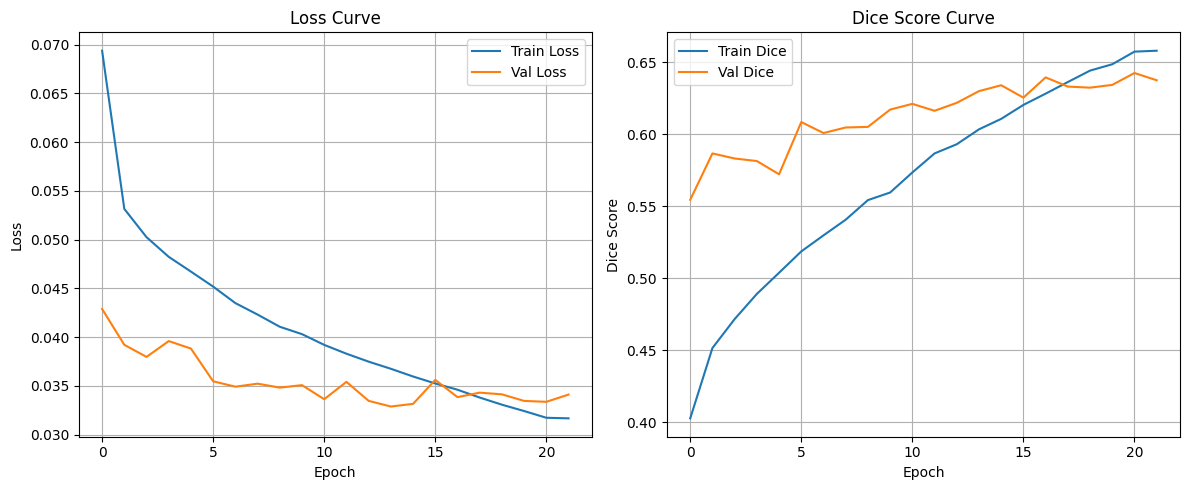

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [20]:
train_model(model_2D_UNET, train_dataset, val_dataset, num_epochs=25)

In [21]:
def save_model(model, path):
    torch.save(model.state_dict(), path)
    print(f"Model saved to: {path}")

In [22]:
model_path = 'models/2D_UNET.pth'
os.makedirs('./models', exist_ok=True)
save_model(model_2D_UNET, model_path)

Model saved to: models/2D_UNET.pth


Evaluating: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5028/5028 [01:05<00:00, 77.29it/s]



 Evaluation Results:
  Dice Class 0: 0.9971
  Dice Class 1: 0.6137
  Dice Class 2: 0.4435
  Dice Class 3: 0.5549
  Pixel Accuracy: 0.9891
  Confusion Matrix:
[[320686808    540395     13890     57928]
 [   872608   3649186    121413    309400]
 [   223343    324051    581224    423936]
 [   130834    325147    242372   1012473]]


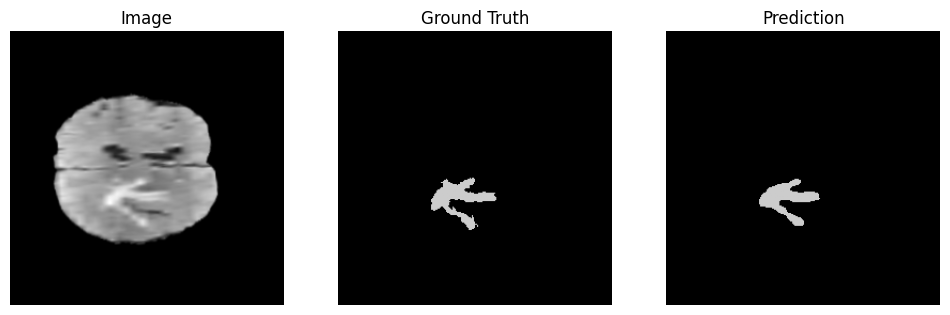

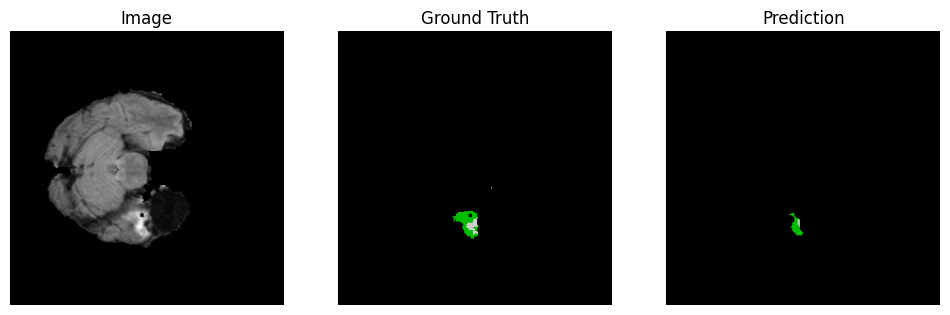

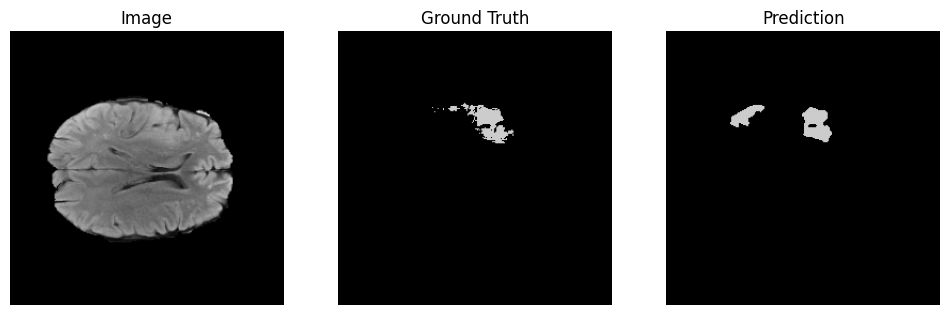

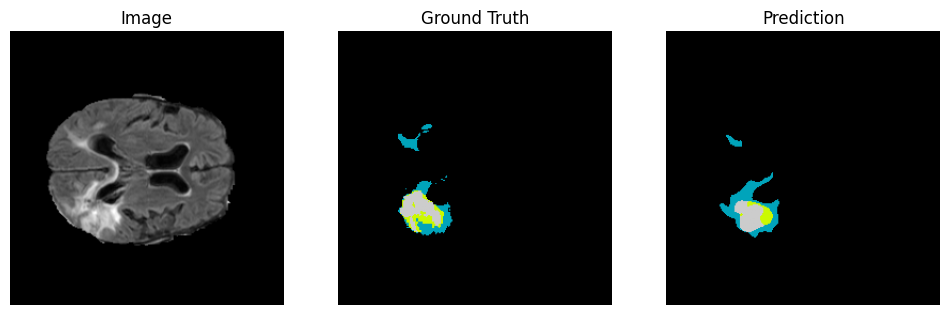

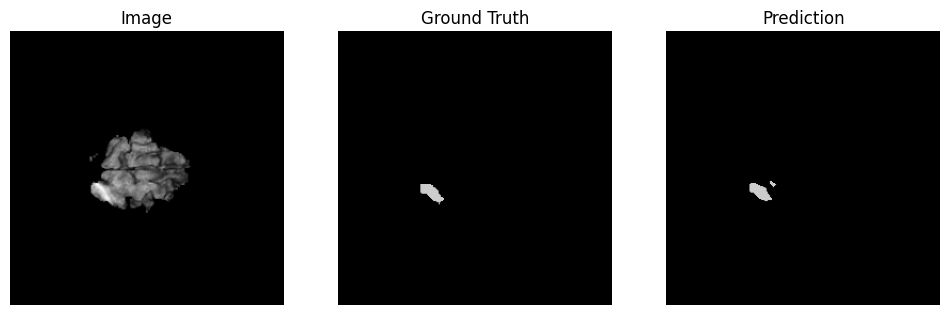

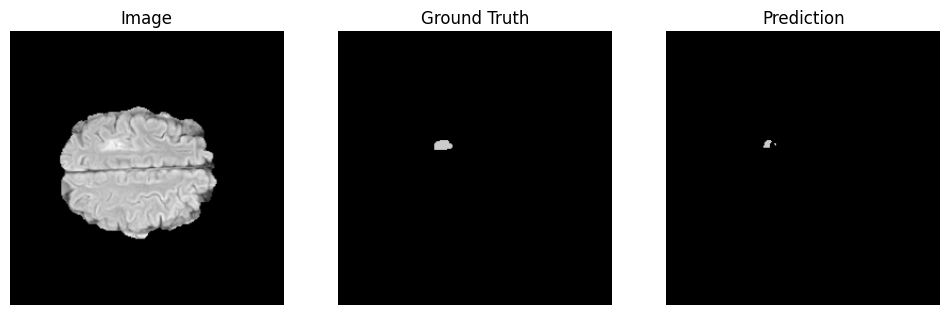

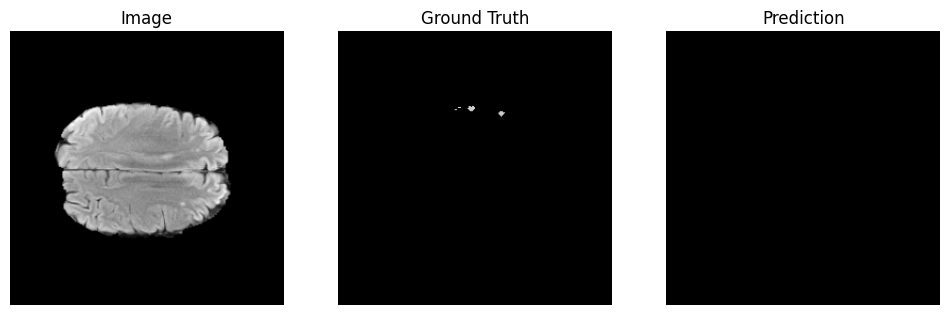

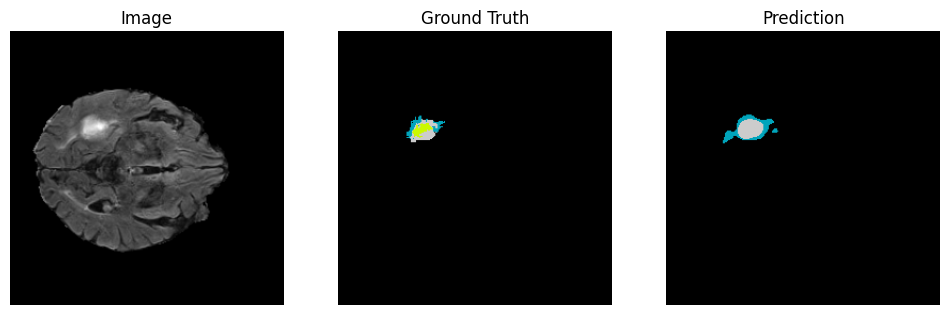

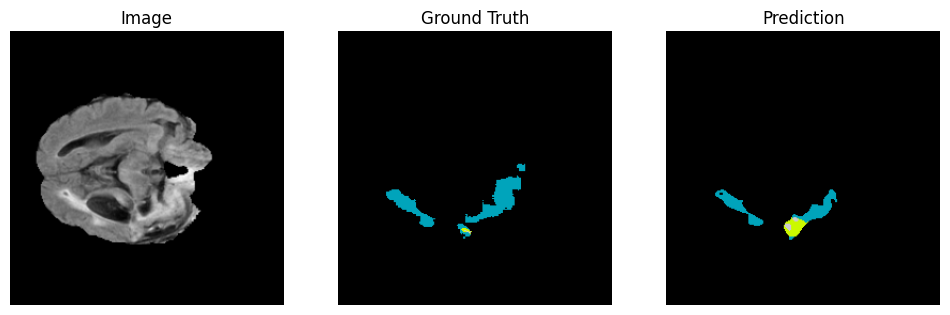

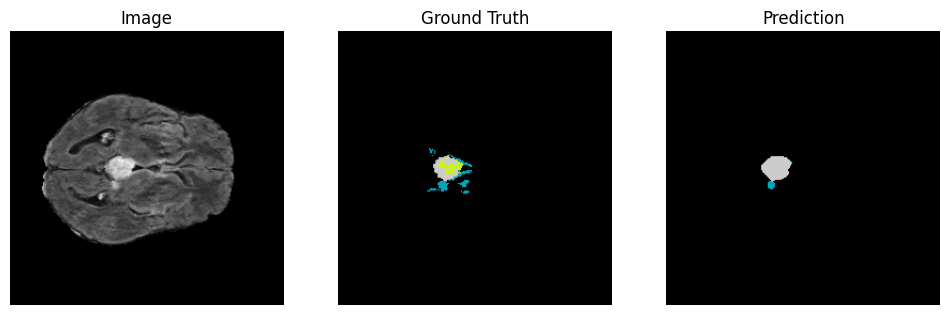

In [23]:
evaluate_metrics(model_2D_UNET, test_dataset)
visualize_predictions(model_2D_UNET, test_dataset, num_samples=10)

Epoch 1/25: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2958/2958 [02:38<00:00, 18.65it/s, loss=0.112]


Train Loss: 0.0699, Dice: 0.3849
Val Loss: 0.0460, Dice: 0.5533
Best model saved at epoch 1.


Epoch 2/25: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2958/2958 [02:16<00:00, 21.72it/s, loss=0.0244]


Train Loss: 0.0538, Dice: 0.4464
Val Loss: 0.0392, Dice: 0.5703
Best model saved at epoch 2.


Epoch 3/25: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2958/2958 [02:17<00:00, 21.47it/s, loss=0.0367]


...

Train Loss: 0.0341, Dice: 0.6283
Val Loss: 0.0335, Dice: 0.6383


Epoch 19/25: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2958/2958 [02:21<00:00, 20.89it/s, loss=0.0295]


Train Loss: 0.0337, Dice: 0.6327
Val Loss: 0.0336, Dice: 0.6378


Epoch 20/25: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2958/2958 [02:20<00:00, 21.00it/s, loss=0.0289]


Train Loss: 0.0325, Dice: 0.6434
Val Loss: 0.0333, Dice: 0.6367
Early stopping triggered.


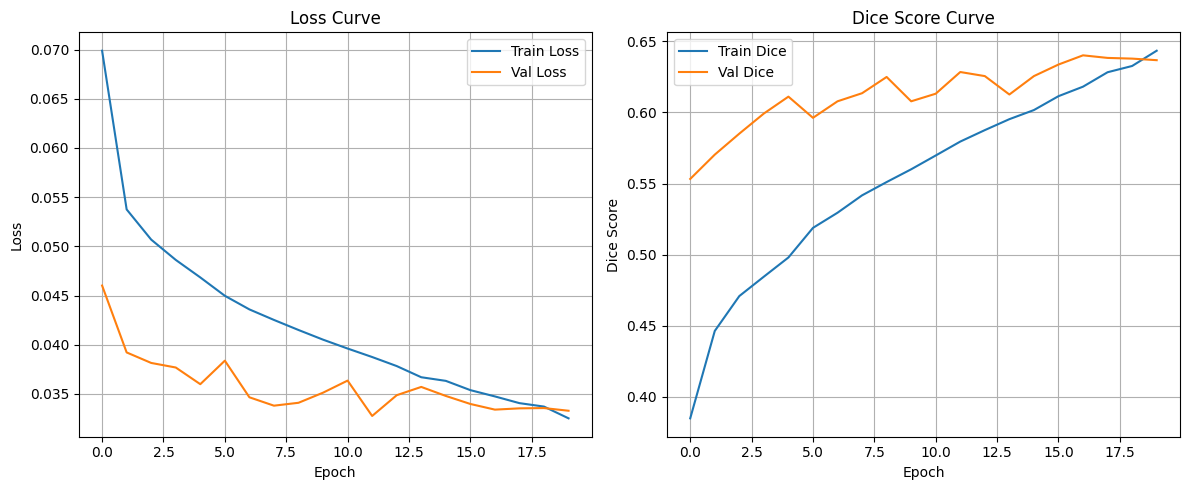

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [24]:
train_model(model_2D_UNET_pretrained, train_dataset, val_dataset, num_epochs=25)

In [25]:
model_path = 'models/2D_UNET_pretrained.pth'
save_model(model_2D_UNET_pretrained, model_path)

Model saved to: models/2D_UNET_pretrained.pth


Evaluating: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5028/5028 [01:06<00:00, 75.39it/s]



 Evaluation Results:
  Dice Class 0: 0.9970
  Dice Class 1: 0.6120
  Dice Class 2: 0.4173
  Dice Class 3: 0.5649
  Pixel Accuracy: 0.9890
  Confusion Matrix:
[[320720843    512410     12733     53035]
 [   980965   3675191    102434    194017]
 [   235061    365404    479163    472926]
 [   135134    383743    188478   1003471]]


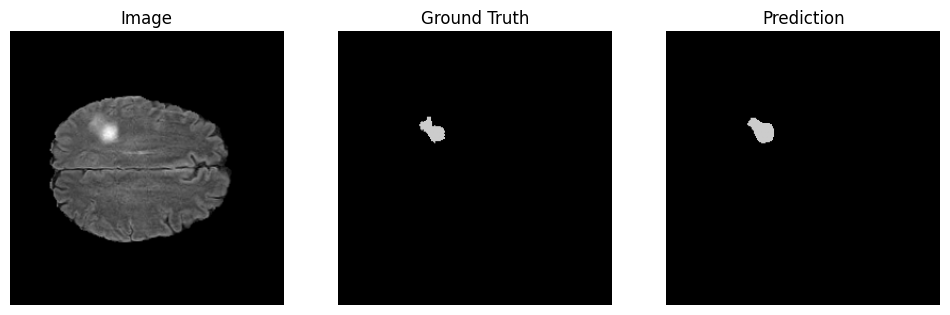

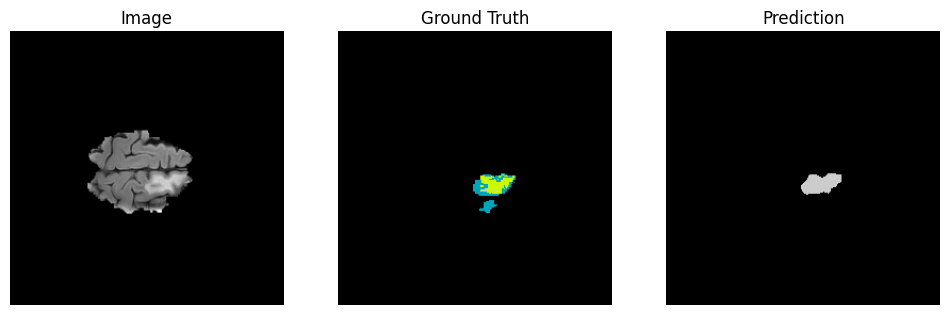

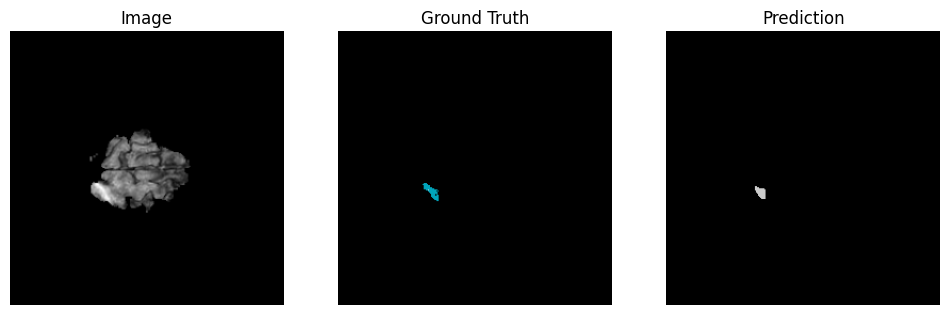

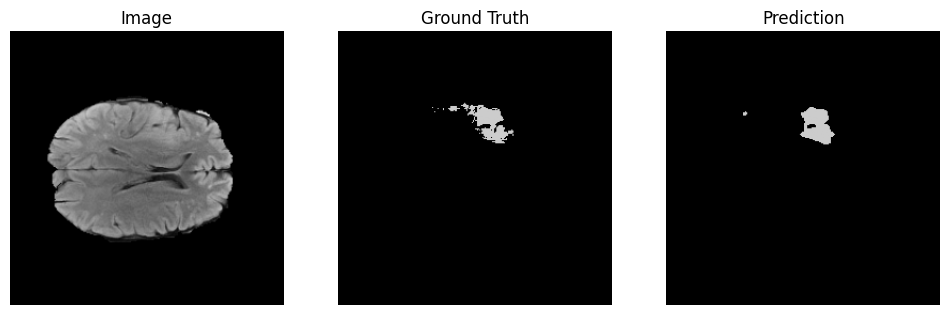

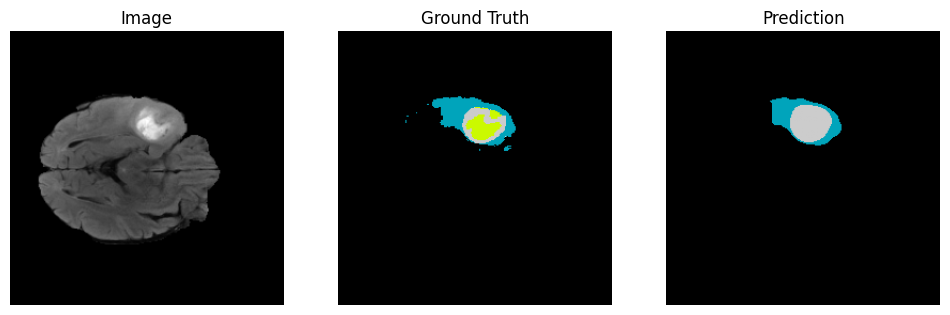

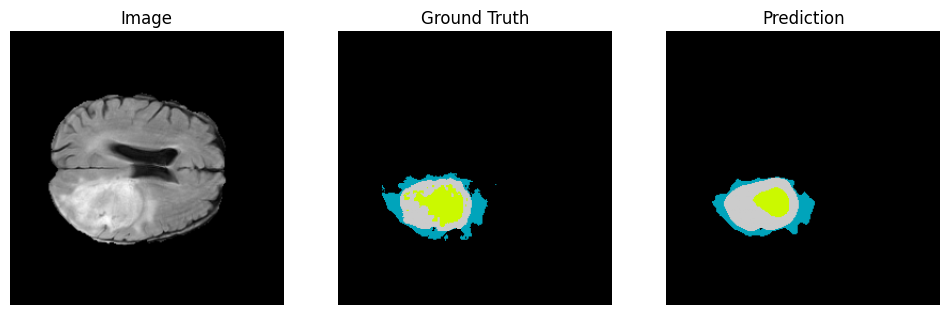

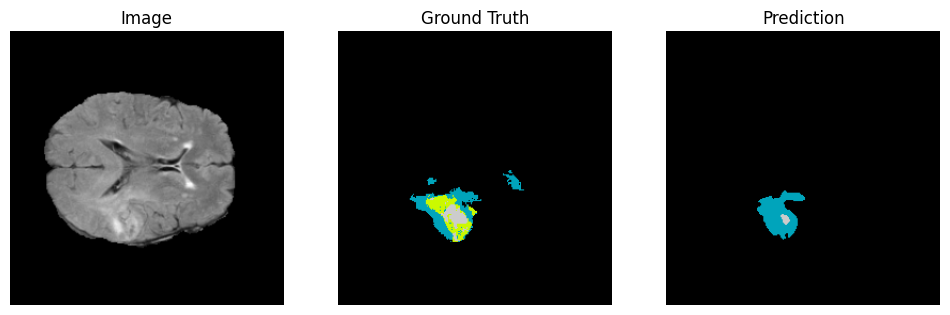

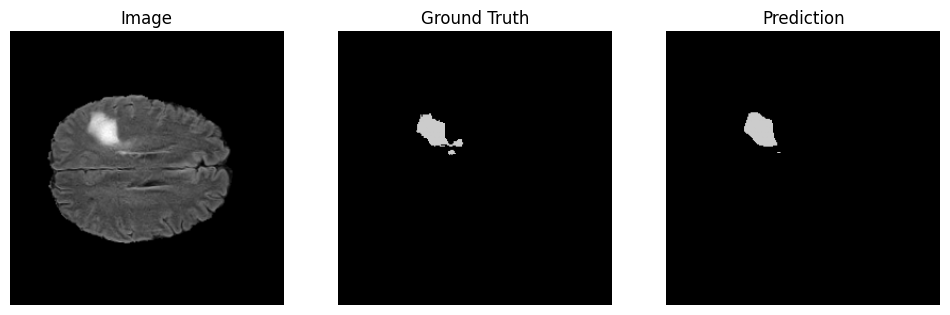

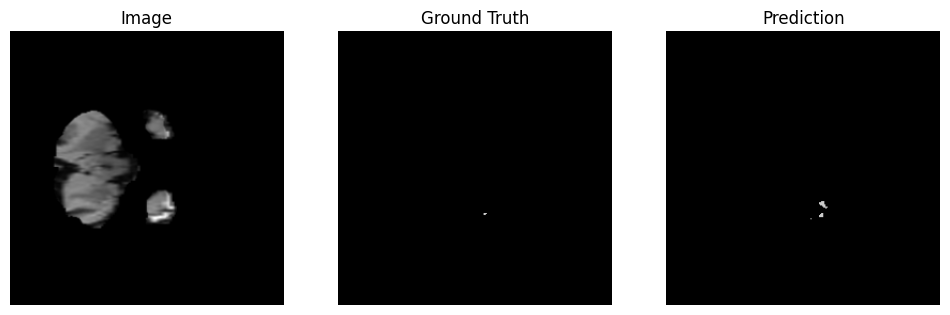

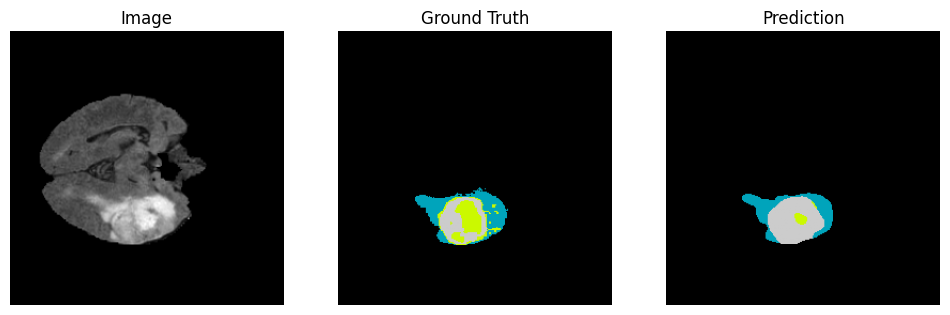

In [26]:
evaluate_metrics(model_2D_UNET_pretrained, test_dataset)
visualize_predictions(model_2D_UNET_pretrained, test_dataset, num_samples=10)